<a href="https://colab.research.google.com/github/Kmpi17/TFMGreenWashing/blob/main/TFG_KMPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import gdown
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

file_id='1TIVB9XokgA-2zQrHpkZbu-Zb1fvor87J'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'productos_espana.csv'
gdown.download(url, output, quiet=False)
df_products = pd.read_csv(output, low_memory=False)
print("Archivo cargado con éxito")

Downloading...
From (original): https://drive.google.com/uc?id=1TIVB9XokgA-2zQrHpkZbu-Zb1fvor87J
From (redirected): https://drive.google.com/uc?id=1TIVB9XokgA-2zQrHpkZbu-Zb1fvor87J&confirm=t&uuid=3dd3e0bf-dead-42a1-b053-7e9c1eb97025
To: /content/productos_espana.csv
100%|██████████| 1.06G/1.06G [00:19<00:00, 53.7MB/s]


Archivo cargado con éxito


# **ANALISIS PREVIO DEL DATASET**

Celda usada para ver en mas profundidad el contenido del dataset

In [ ]:
print("TODO LOS NOMBRE DE COLUMNAS ")
print(df_products.columns.tolist())
print("------------")
print(df_products.iloc[1900].to_string())

TODO LOS NOMBRE DE COLUMNAS 
['code', 'url', 'creator', 'created_t', 'created_datetime', 'last_modified_t', 'last_modified_datetime', 'last_modified_by', 'last_updated_t', 'last_updated_datetime', 'product_name', 'abbreviated_product_name', 'generic_name', 'quantity', 'packaging', 'packaging_tags', 'packaging_en', 'packaging_text', 'brands', 'brands_tags', 'brands_en', 'categories', 'categories_tags', 'categories_en', 'origins', 'origins_tags', 'origins_en', 'manufacturing_places', 'manufacturing_places_tags', 'labels', 'labels_tags', 'labels_en', 'emb_codes', 'emb_codes_tags', 'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places', 'stores', 'countries', 'countries_tags', 'countries_en', 'ingredients_text', 'ingredients_tags', 'ingredients_analysis_tags', 'allergens', 'allergens_en', 'traces', 'traces_tags', 'traces_en', 'serving_size', 'serving_quantity', 'no_nutrition_data', 'additives_n', 'additives', 'additives_tags', 'additives_en', 'nutriscore_score', 'nutriscore

Celda usada para ver informacion generica sobre el dataset

In [ ]:
print("Numero de columnas y nombres")
print(df_products.columns)
print("------------")
print(f"Total de columnas {len(df_products.columns)}")
print("------------")
print(f"Totel de registros {len(df_products)}")
print("------------")
print(f"Valores nulos")
nulos=df_products.isnull().sum().sum()
print(nulos)
print("------------")
print("Valores duplicados")
duplicados=df_products.duplicated().sum()
print(duplicados)
print("------------")
print("Tipos de datos")
print(df_products.dtypes)
print("------------")


Numero de columnas y nombres
Index(['code', 'url', 'creator', 'created_t', 'created_datetime',
       'last_modified_t', 'last_modified_datetime', 'last_modified_by',
       'last_updated_t', 'last_updated_datetime',
       ...
       'water-hardness_100g', 'choline_100g', 'phylloquinone_100g',
       'beta-glucan_100g', 'inositol_100g', 'carnitine_100g', 'sulphate_100g',
       'nitrate_100g', 'acidity_100g', 'carbohydrates-total_100g'],
      dtype='object', length=209)
------------
Total de columnas 209
------------
Totel de registros 352707
------------
Valores nulos
60038572
------------
Valores duplicados
0
------------
Tipos de datos
code                         object
url                          object
creator                      object
created_t                     int64
created_datetime             object
                             ...   
carnitine_100g              float64
sulphate_100g               float64
nitrate_100g                float64
acidity_100g               

# **PROCESO DE LIMPIEZA**

Previamente vamos al dataset a hacer una copia en una variable para posteriormente comparar entre ellos todos los cambios

In [ ]:
df_products_copy=df_products.copy()

ELIMINACION DE FILAS VACIAS

In [ ]:
print(f"Totel de registros antes:{len(df_products_copy)}")
df_products_copy=df_products_copy.dropna(how="all")
print(f"Totel de registros despues:{len(df_products_copy)}")

Totel de registros antes:352707
Totel de registros despues:352707


LIMPIEZA DE COLUMNAS INECESARIAS

In [ ]:
print(f"Numero de columnas antes:{len(df_products_copy.columns)}")
columnas_utilizadas=['code', 'product_name', 'brands', 'categories_en', 'labels_tags','nutriscore_grade', 'energy-kcal_100g',
    'fat_100g', 'saturated-fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g','additives_n','additives_tags']

df_products_copy=df_products_copy[columnas_utilizadas]

print(f"Numero de columnas despues:{len(df_products_copy.columns)}")

Numero de columnas antes:209
Numero de columnas despues:14


In [ ]:
print("\n1️⃣ Información General:")
print(df_products_copy.info())
print("------------")
print("\n2️⃣ Estadísticas Descriptivas:")
display(df_products_copy.describe())


1️⃣ Información General:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352707 entries, 0 to 352706
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                352707 non-null  object 
 1   product_name        332307 non-null  object 
 2   brands              214028 non-null  object 
 3   categories_en       132162 non-null  object 
 4   labels_tags         121580 non-null  object 
 5   nutriscore_grade    351932 non-null  object 
 6   energy-kcal_100g    21416 non-null   float64
 7   fat_100g            21267 non-null   float64
 8   saturated-fat_100g  20817 non-null   float64
 9   sugars_100g         20918 non-null   float64
 10  proteins_100g       21291 non-null   float64
 11  salt_100g           20795 non-null   float64
 12  additives_n         51261 non-null   float64
 13  additives_tags      27818 non-null   object 
dtypes: float64(7), object(7)
memory usage: 37.7+ MB
None
-----

,energy-kcal_100g,fat_100g,saturated-fat_100g,sugars_100g,proteins_100g,salt_100g,additives_n
count,2.141600e+04,21267.000000,20817.000000,20918.000000,21291.000000,20795.000000,51261.000000
mean,3.569451e+02,12.663792,4.555092,12.646282,7.970327,1.394834,1.845341
std,1.320812e+04,17.026554,7.286075,17.841805,10.135380,23.467640,2.979229
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.400000e+01,1.000000,0.200000,1.300000,2.000000,0.070000,0.000000
50%,2.440000e+02,5.200000,1.600000,4.800000,5.300000,0.220000,1.000000
75%,4.150000e+02,20.000000,5.600000,15.600000,10.000000,1.000000,3.000000
max,1.932459e+06,100.000000,100.000000,420.000000,100.000000,2480.000000,319.000000


**ANALISIS DE COMPLETITUD**

In [ ]:
valores_faltantes = df_products_copy.isnull().sum()
porcentaje_faltos = (valores_faltantes / len(df_products_copy)) * 100

df_faltantes = pd.DataFrame({
    'Valores Faltantes': valores_faltantes,
    'Porcentaje de Faltantes': porcentaje_faltos
})

print("Análisis de Completitud de Columnas:")
print(df_faltantes.sort_values(by='Porcentaje de Faltantes', ascending=False))

Análisis de Completitud de Columnas:
                    Valores Faltantes  Porcentaje de Faltantes
salt_100g                      331912                94.104171
saturated-fat_100g             331890                94.097934
sugars_100g                    331789                94.069298
fat_100g                       331440                93.970349
proteins_100g                  331416                93.963545
energy-kcal_100g               331291                93.928105
additives_tags                 324889                92.113000
additives_n                    301446                85.466407
labels_tags                    231127                65.529462
categories_en                  220545                62.529238
brands                         138679                39.318471
product_name                    20400                 5.783838
nutriscore_grade                  775                 0.219729
code                                0                 0.000000


Análisis de Completitud de Columnas (Gráfico):


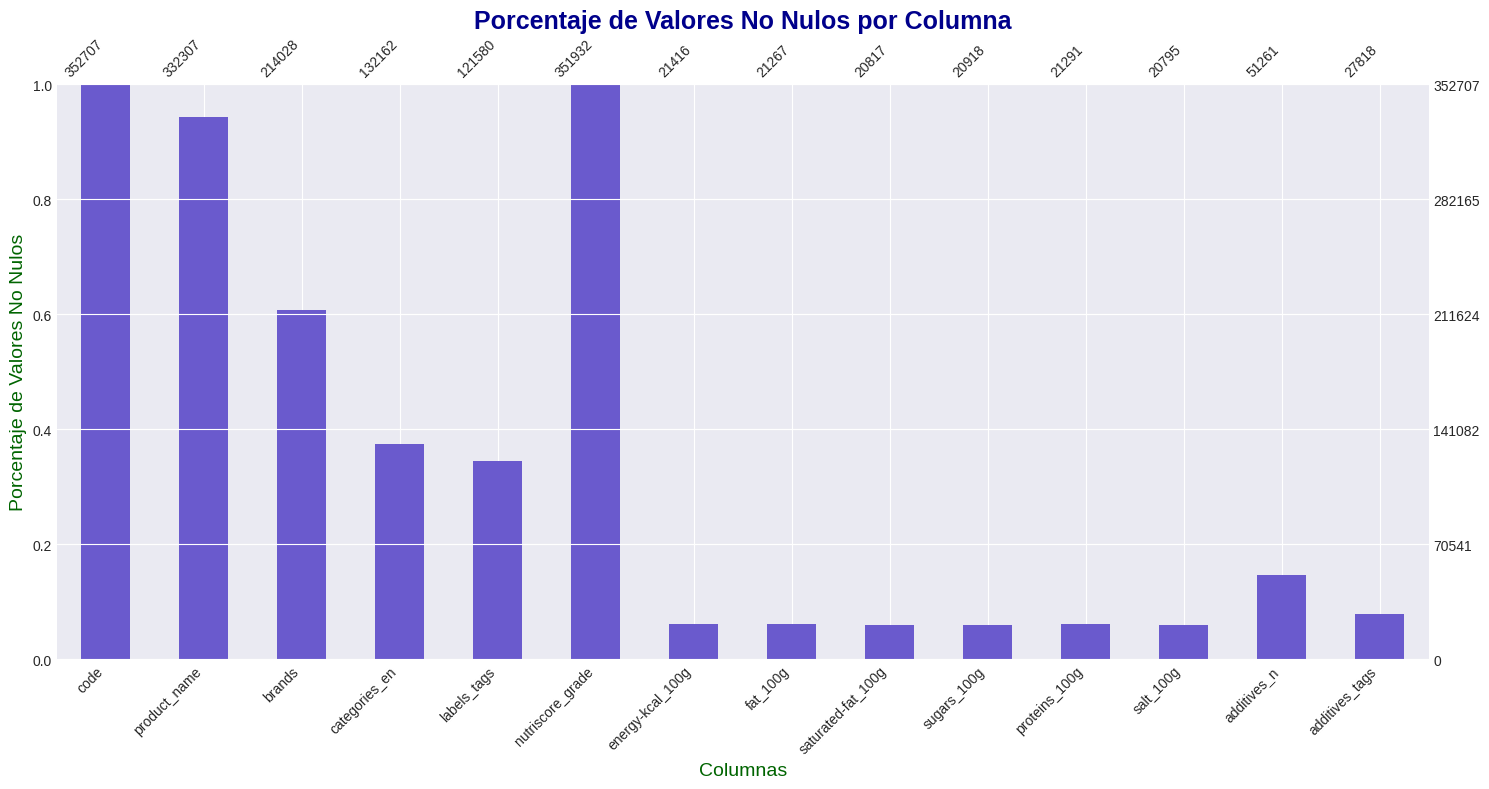

In [ ]:

print("Análisis de Completitud de Columnas (Gráfico):")

plt.style.use('seaborn-v0_8-darkgrid')

ax = msno.bar(df_products_copy, figsize=(15, 8), color="#6A5ACD", fontsize=10, labels=True)

ax.set_title('Porcentaje de Valores No Nulos por Columna', fontsize=18, color='darkblue', fontweight='bold')
ax.set_xlabel('Columnas', fontsize=14, color='darkgreen')
ax.set_ylabel('Porcentaje de Valores No Nulos', fontsize=14, color='darkgreen')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**LIMPIEZA DE VALORES NULOS**

en este caso vamos a eliminar todos los registros en los cuales las calorias y los azucares sean nulos debido a que se va a priorizar la integridad del modelo en un futuro sobre el volumen de datos

In [ ]:
print(f"Totel de registros antes:{len(df_products_copy)}")
df_products_copy=df_products_copy.dropna(subset=['energy-kcal_100g', 'sugars_100g'])
print(f"Totel de registros despues:{len(df_products_copy)}")


Totel de registros antes:352707
Totel de registros despues:20904


In [ ]:
print(df_products_copy.iloc[2191].to_string())

code                                                           27025840
product_name                                              Mini Grissini
brands                                                              NaN
categories_en         Plant-based foods and beverages,Plant-based fo...
labels_tags                                                         NaN
nutriscore_grade                                                      d
energy-kcal_100g                                                  427.0
fat_100g                                                           13.0
saturated-fat_100g                                                  2.0
sugars_100g                                                         2.5
proteins_100g                                                      10.0
salt_100g                                                           2.0
additives_n                                                         NaN
additives_tags                                                  

**EXPLICACION DE DISMINUCION**

como se puede ver la cantidad de registros ha disminuido de gran forma esta es debido a que por un lado se esta priorizando la calidad del modelo por tanto no se usaran registros con informacion incompleta ya que nuestro modelo no seria acertado, por otro lado la API utilizada es comunitaria por tanto hay muchos registros "basura" con informacion incompleta, por tanto al priorizarse la calidad frente a la cantidad da este resultado

In [ ]:
print(f"Totel de registros antes:{len(df_products_copy)}")
df_products_copy = df_products_copy[
    ((df_products_copy['fat_100g'] +
      df_products_copy['sugars_100g'] +
      df_products_copy['proteins_100g']+
      df_products_copy['salt_100g']) <= 100) &
    (df_products_copy['energy-kcal_100g'] > 0)
]

df_products_copy=df_products_copy[df_products_copy['fat_100g'] >= df_products_copy['saturated-fat_100g']]
df_products_copy=df_products_copy.dropna(subset=['product_name','code','brands','categories_en'])
df_products_copy=df_products_copy.drop_duplicates(subset=['code'])



print(f"Totel de registros despues:{len(df_products_copy)}")

Totel de registros antes:20904
Totel de registros despues:17410


In [ ]:
print(df_products_copy.iloc[2191].to_string())

code                                                      3245412404474
product_name                                            Bizcocho al ron
brands                                                        Carrefour
categories_en         Dairies,Snacks,Desserts,Sweet snacks,Biscuits ...
labels_tags           en:non-organic,en:nutriscore,en:nutriscore-gra...
nutriscore_grade                                                      d
energy-kcal_100g                                                  186.0
fat_100g                                                            3.3
saturated-fat_100g                                                  2.2
sugars_100g                                                        25.0
proteins_100g                                                       1.7
salt_100g                                                          0.16
additives_n                                                         2.0
additives_tags                                          en:e410,

In [ ]:
def normalizar_string(valor):
  if pd.isna(valor):
    return np.nan
  valor=str(valor).lower().strip().replace("á","a").replace("é","e").replace("í","i").replace("ó","o").replace("ú","u").strip()
  return valor


def separar_categorias_marcas(valor):
  if pd.isna(valor):
    return np.nan
  valor=str(valor).split(",")
  return valor[0]


def limpiar_tags_aditivos(valor):
    if pd.isna(valor):
        return "no_tag"
    valor = str(valor).replace('en:', '')
    return valor

En esta celda se esta dando un formato comun para en un futuro faticilar el estudio de los datos.


In [ ]:
df_products_copy['product_name']=df_products_copy['product_name'].apply(normalizar_string)
df_products_copy['brands']=df_products_copy['brands'].apply(normalizar_string)
df_products_copy['categories_en']=df_products_copy['categories_en'].apply(normalizar_string)
df_products_copy['labels_tags']=df_products_copy['labels_tags'].apply(normalizar_string)
df_products_copy['additives_tags']=df_products_copy['additives_tags'].apply(normalizar_string)

df_products_copy['brands']=df_products_copy['brands'].apply(separar_categorias_marcas)
df_products_copy['categories_en']=df_products_copy['categories_en'].apply(separar_categorias_marcas)

df_products_copy['additives_n'] = df_products_copy['additives_n'].fillna(0)
df_products_copy['additives_n'] = df_products_copy['additives_n'].astype(int)


df_products_copy['nutriscore_grade'] = df_products_copy['nutriscore_grade'].replace(['not-applicable', 'unknown'], np.nan)


df_products_copy['additives_tags'] = df_products_copy['additives_tags'].apply(limpiar_tags_aditivos)


en un futuro habra q hacer tablas binarias para entrenar el modelo sobre los tags

In [ ]:
print(df_products_copy.iloc[2191].to_string())

code                                                      3245412404474
product_name                                            bizcocho al ron
brands                                                        carrefour
categories_en                                                   dairies
labels_tags           en:non-organic,en:nutriscore,en:nutriscore-gra...
nutriscore_grade                                                      d
energy-kcal_100g                                                  186.0
fat_100g                                                            3.3
saturated-fat_100g                                                  2.2
sugars_100g                                                        25.0
proteins_100g                                                       1.7
salt_100g                                                          0.16
additives_n                                                           2
additives_tags                                                e4

In [ ]:
print(df_products_copy.head(50).to_string())

             code                                            product_name                                        brands                         categories_en                                                                                                                                                                                                                                      labels_tags nutriscore_grade  energy-kcal_100g   fat_100g  saturated-fat_100g  sugars_100g  proteins_100g  salt_100g  additives_n                                    additives_tags
66           1065                                   boisson à l'aloe vera                                     herbalife       plant-based foods and beverages                                                                                                                                                                                                                                              NaN              NaN         12.000000

**PROBLEMA ADITIVOS**

En el dataset me acabo de encontrar con el problema de q los aditivos tienen un codigo q los identifica, por otro lado tiene un numero de cuantos ahi , el problema de esto esq no coinciden muchas veces estos numeros por tanto esto a la larga va a provocar q el modelo no sea cierto , por tanto he llegado a la conclusion de q es mejor borrar esos registros.

In [ ]:
def contar_tags_reales(valor):
    if pd.isna(valor) or str(valor).strip() == "" or str(valor) == "no_tag":
        return 0
    return len(str(valor).split(','))

In [ ]:
print(f"Totel de registros antes:{len(df_products_copy)}")

df_products_copy['verificacion_additives'] = df_products_copy['additives_tags'].apply(contar_tags_reales)
df_products_copy = df_products_copy[df_products_copy['additives_n'] == df_products_copy['verificacion_additives']].copy()
df_products_copy.drop(columns=['verificacion_additives'], inplace=True)

print(f"Totel de registros antes:{len(df_products_copy)}")


Totel de registros antes:17410
Totel de registros antes:15350


In [ ]:
print(df_products_copy.head(50).to_string())

             code                                            product_name                                        brands                         categories_en                                                                                                                                                                                                                                      labels_tags nutriscore_grade  energy-kcal_100g   fat_100g  saturated-fat_100g  sugars_100g  proteins_100g  salt_100g  additives_n                            additives_tags
66           1065                                   boisson à l'aloe vera                                     herbalife       plant-based foods and beverages                                                                                                                                                                                                                                              NaN              NaN         12.000000   0.000

# **ANALISIS UNA VEZ LIMPIO**

**COMPLETITUD DESPUES**

In [ ]:
valores_faltantes = df_products_copy.isnull().sum()
porcentaje_faltos = (valores_faltantes / len(df_products_copy)) * 100

df_faltantes = pd.DataFrame({
    'Valores Faltantes': valores_faltantes,
    'Porcentaje de Faltantes': porcentaje_faltos
})

print("Análisis de Completitud de Columnas:")
print(df_faltantes.sort_values(by='Porcentaje de Faltantes', ascending=False))

Análisis de Completitud de Columnas:
                    Valores Faltantes  Porcentaje de Faltantes
labels_tags                      5481                35.706840
nutriscore_grade                  971                 6.325733
product_name                        0                 0.000000
code                                0                 0.000000
categories_en                       0                 0.000000
brands                              0                 0.000000
energy-kcal_100g                    0                 0.000000
fat_100g                            0                 0.000000
saturated-fat_100g                  0                 0.000000
sugars_100g                         0                 0.000000
proteins_100g                       0                 0.000000
salt_100g                           0                 0.000000
additives_n                         0                 0.000000
additives_tags                      0                 0.000000


Análisis de Completitud de Columnas (Gráfico):


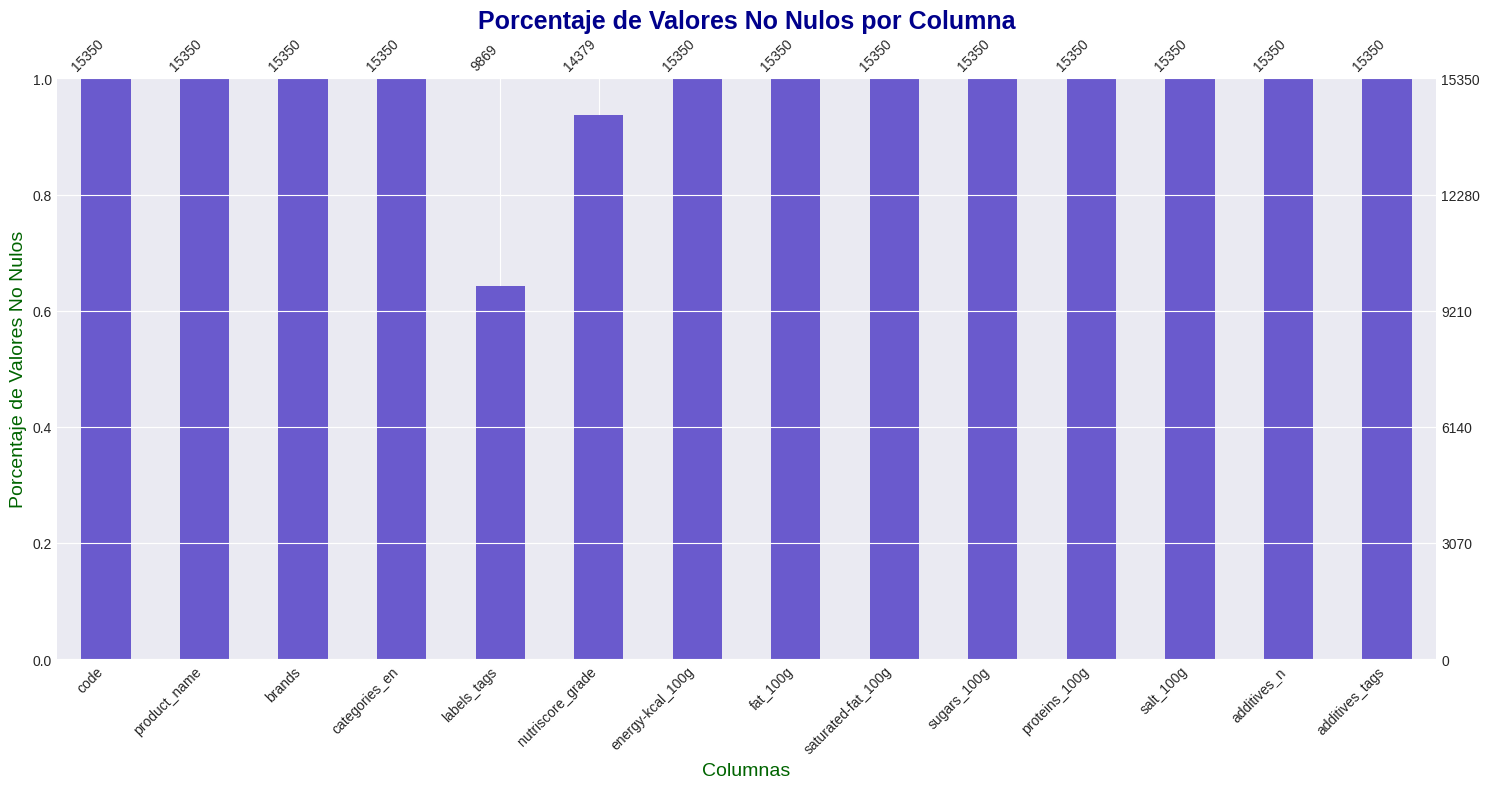

In [ ]:

print("Análisis de Completitud de Columnas (Gráfico):")

plt.style.use('seaborn-v0_8-darkgrid')

ax = msno.bar(df_products_copy, figsize=(15, 8), color="#6A5ACD", fontsize=10, labels=True)

ax.set_title('Porcentaje de Valores No Nulos por Columna', fontsize=18, color='darkblue', fontweight='bold')
ax.set_xlabel('Columnas', fontsize=14, color='darkgreen')
ax.set_ylabel('Porcentaje de Valores No Nulos', fontsize=14, color='darkgreen')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**OUTLINERS**

He decidido hacer el metodo IQR para detectar outliners sin embargo en este caso no tiene mucho sentido debido a que esto depende de cada tipo de alimentos por tanto que  tengan valores altos no significa que estos esten mal todo lo contrario si no hubiese seria indicativo de que hay algo raro en el dataset, ejemplo de esto podria ser la sal pura o azucar que obviamente van a tener este valor mas alto etc... Aun asi creo que es interesante ver un poco mas de cerca todos estos valores.

Por otro lado destacar que anteriormente ya se ha echo un filtro para todos los valores anormales y que no tienen coherencia entre si

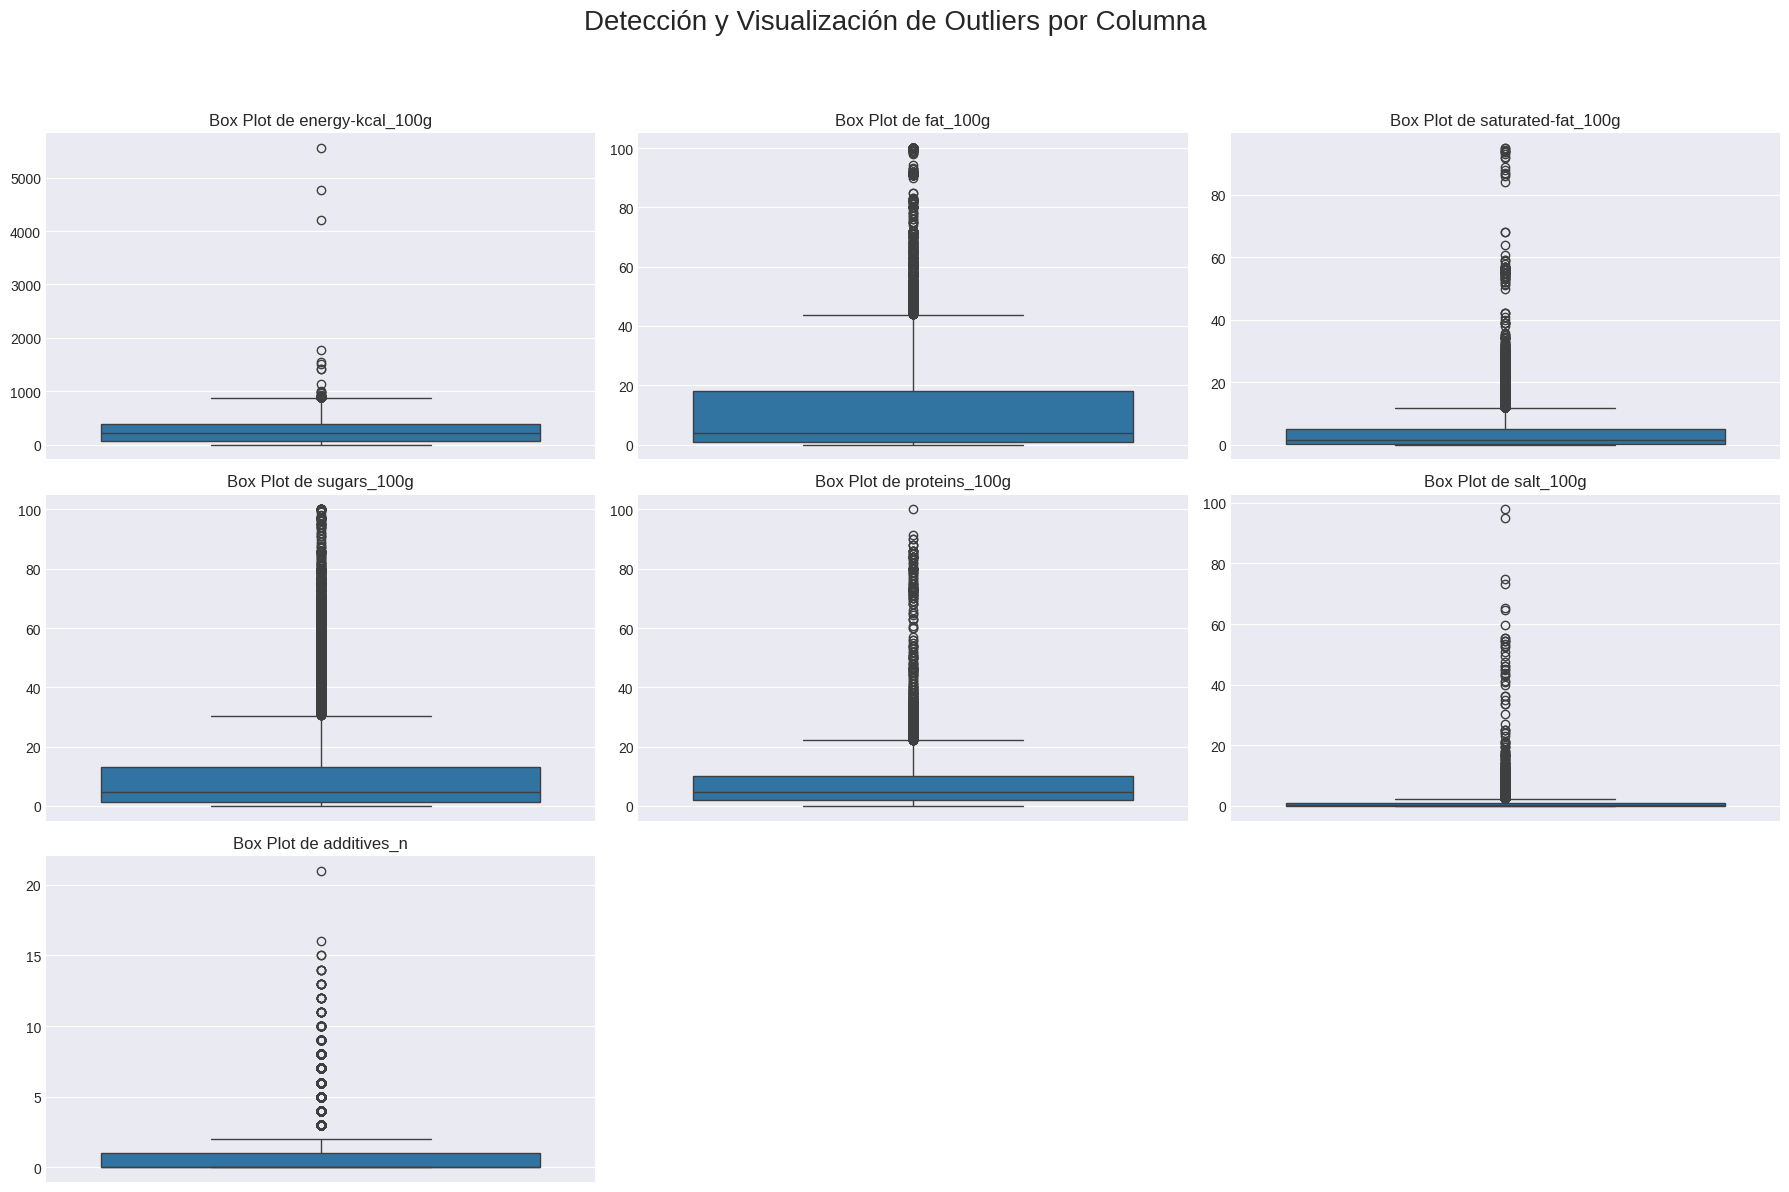


--- Conteo de Outliers Detectados (Método IQR) ---
Columna 'energy-kcal_100g': 117 outliers
Columna 'fat_100g': 819 outliers
Columna 'saturated-fat_100g': 1851 outliers
Columna 'sugars_100g': 1756 outliers
Columna 'proteins_100g': 1069 outliers
Columna 'salt_100g': 906 outliers
Columna 'additives_n': 2335 outliers


In [ ]:


columnas_numericas = [
    'energy-kcal_100g',
    'fat_100g',
    'saturated-fat_100g',
    'sugars_100g',
    'proteins_100g',
    'salt_100g',
    'additives_n'
]

numero_outliners = {}

plt.figure(figsize=(18, 12))
plt.suptitle('Detección y Visualización de Outliers por Columna', fontsize=20, y=1.02)

for i, col in enumerate(columnas_numericas):
    if col in df_products_copy.columns and df_products_copy[col].dtype in ['float64', 'int64']:

        Q1 = df_products_copy[col].quantile(0.25)
        Q3 = df_products_copy[col].quantile(0.75)
        IQR = Q3 - Q1


        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR


        col_outliers = df_products_copy[(df_products_copy[col] < lower_bound) | (df_products_copy[col] > upper_bound)]
        numero_outliners[col] = len(col_outliers)


        plt.subplot(3, 3, i + 1)
        sns.boxplot(y=df_products_copy[col])
        plt.title(f'Box Plot de {col}')
        plt.ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\n--- Conteo de Outliers Detectados (Método IQR)")
for col, count in numero_outliners.items():
    print(f"Columna '{col}': {count} outliers")


**RESULTADOS LIMPIEZA ANTES VS DESPUES**

In [ ]:
data = {
    'Parametro': ['Registros', 'Columnas', 'Nulos'],
    'df_products (Original)': [
        len(df_products),
        len(df_products.columns),
        df_products.isnull().sum().sum()
    ],
    'df_products_copy (Limpio)': [
        len(df_products_copy),
        len(df_products_copy.columns),
        df_products_copy.isnull().sum().sum()
    ]
}

df_comparison = pd.DataFrame(data)
display(df_comparison)


,Parametro,df_products (Original),df_products_copy (Limpio)
0,Registros,352707,15350
1,Columnas,209,14
2,Nulos,60038572,6452


**ESTADISTICAS DEL DATASET**

In [ ]:
print("\n1️⃣ Información General:")
print(df_products_copy.info())
print("------------")
print("\n2️⃣ Estadísticas Descriptivas:")
display(df_products_copy.describe())
print("------------")
print("\n3️⃣ Top 10 Productos con mas aditivos:")
top_additives = df_products_copy.nlargest(10, 'additives_n')[['product_name', 'brands', 'additives_n', 'nutriscore_grade']]
display(top_additives)
print("------------")
print("\n4️⃣ Distribución del NutriScore:")
print(df_products_copy['nutriscore_grade'].value_counts().sort_index())
print("------------")
print("\n5️⃣ Marcas con mayor presencia:")
print(df_products_copy['brands'].value_counts().head(10))
print("------------")


1️⃣ Información General:
<class 'pandas.core.frame.DataFrame'>
Index: 15350 entries, 66 to 352005
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                15350 non-null  object 
 1   product_name        15350 non-null  object 
 2   brands              15350 non-null  object 
 3   categories_en       15350 non-null  object 
 4   labels_tags         9869 non-null   object 
 5   nutriscore_grade    14379 non-null  object 
 6   energy-kcal_100g    15350 non-null  float64
 7   fat_100g            15350 non-null  float64
 8   saturated-fat_100g  15350 non-null  float64
 9   sugars_100g         15350 non-null  float64
 10  proteins_100g       15350 non-null  float64
 11  salt_100g           15350 non-null  float64
 12  additives_n         15350 non-null  int64  
 13  additives_tags      15350 non-null  object 
dtypes: float64(6), int64(1), object(7)
memory usage: 1.8+ MB
None
------------

2️⃣

,energy-kcal_100g,fat_100g,saturated-fat_100g,sugars_100g,proteins_100g,salt_100g,additives_n
count,15350.000000,15350.000000,15350.000000,15350.000000,15350.000000,15350.000000,15350.000000
mean,251.092586,12.026837,4.169277,11.748871,7.644886,0.860060,0.960717
std,209.152726,17.330385,7.175817,17.044287,9.455759,2.928015,1.877535
min,0.063000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,70.000000,0.800000,0.200000,1.300000,1.900000,0.060000,0.000000
50%,211.131999,3.800000,1.300000,4.700000,4.800000,0.190000,0.000000
75%,392.000000,18.000000,4.875000,13.000000,10.000000,1.000000,1.000000
max,5555.000000,100.000000,95.000000,100.000000,100.000000,97.800000,21.000000


------------

3️⃣ Top 10 Productos con mas aditivos:


,product_name,brands,additives_n,nutriscore_grade
296824,sandwich york bacon y queso cremoso lm,lm sandwich,21,e
42828,pollo koreano,joviserrano,16,b
232560,sandwich atun,ñaming,15,c
349225,grilled chicken flavour,yum yum,15,e
75700,party fizz - assortiment de confiseries gelifiees,lutti,14,e
179515,firgas mango fresh,firgas,14,b
179524,flautas de bacon y queso,hacendado,14,e
190754,pantera rosa,bimbo,14,e
21540,deluxe,deluxe villa gusto,13,a
22289,dessert with lemon,deluxe,13,e


------------

4️⃣ Distribución del NutriScore:
nutriscore_grade
a    2282
b    2027
c    3712
d    3174
e    3184
Name: count, dtype: int64
------------

5️⃣ Marcas con mayor presencia:
brands
carrefour        1543
hacendado         682
danone            299
dia               271
nestle            257
auchan            205
carrefour bio     199
milbona           191
eroski            138
prozis            109
Name: count, dtype: int64
------------


GRAFICOS ADICIONALES INTERESANTES

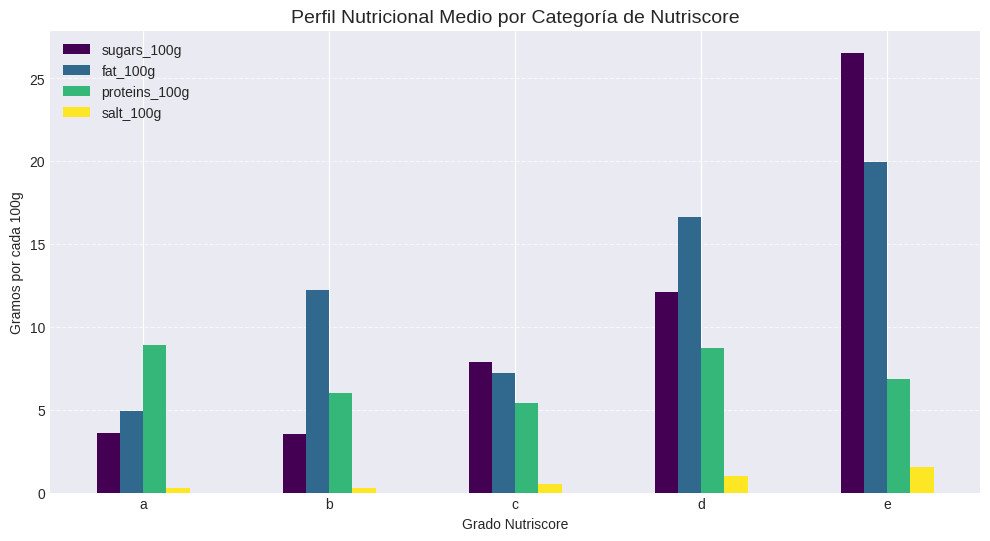

In [ ]:
df_media_por_gramo = df_products_copy.groupby('nutriscore_grade')[['sugars_100g', 'fat_100g', 'proteins_100g', 'salt_100g']].mean()

df_media_por_gramo.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Perfil Nutricional Medio por Categoría de Nutriscore', fontsize=14)
plt.ylabel('Gramos por cada 100g')
plt.xlabel('Grado Nutriscore')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

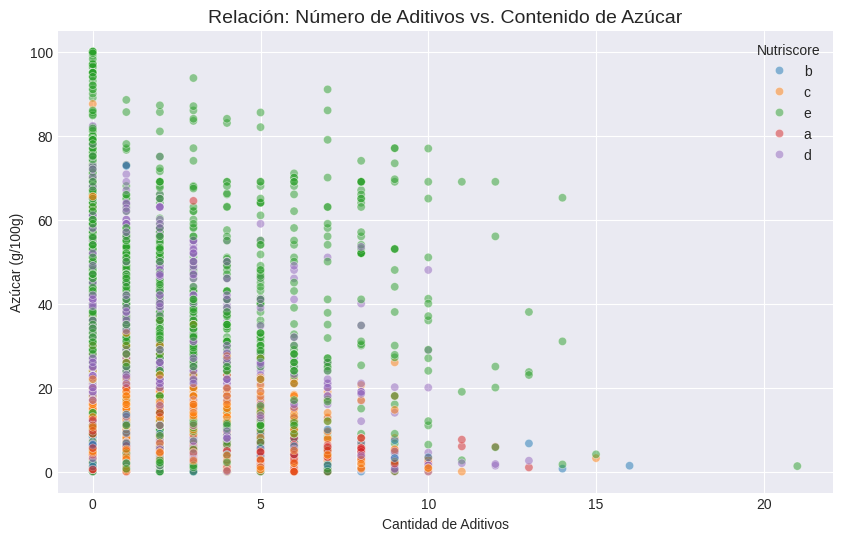

In [458]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_products_copy, x='additives_n', y='sugars_100g', hue='nutriscore_grade',
                palette='RdYlGn_r', alpha=0.5)
plt.title('Relación: Número de Aditivos vs. Contenido de Azúcar', fontsize=14)
plt.xlabel('Cantidad de Aditivos')
plt.ylabel('Azúcar (g/100g)')
plt.legend(title='Nutriscore')
plt.show()

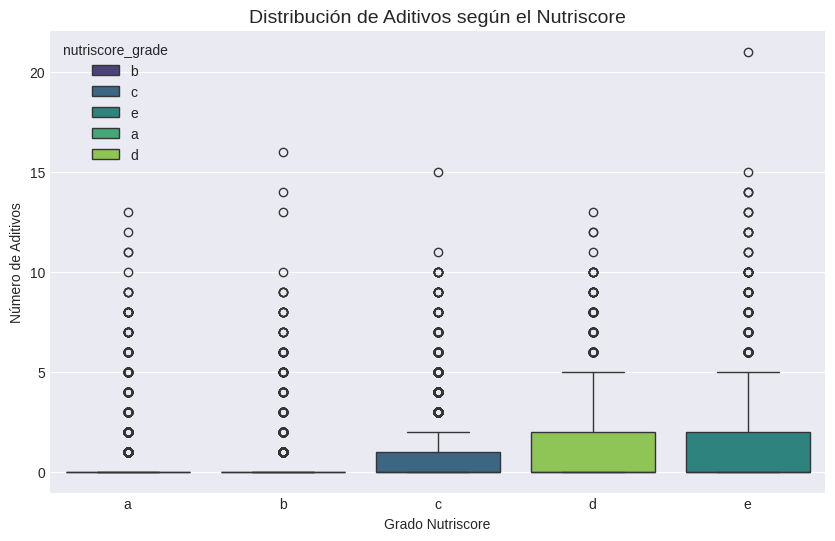

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='nutriscore_grade', y='additives_n', data=df_products_copy, palette='viridis', order=['a', 'b', 'c', 'd', 'e'],hue='nutriscore_grade')
plt.title('Distribución de Aditivos según el Nutriscore', fontsize=14)
plt.xlabel('Grado Nutriscore')
plt.ylabel('Número de Aditivos')
plt.show()

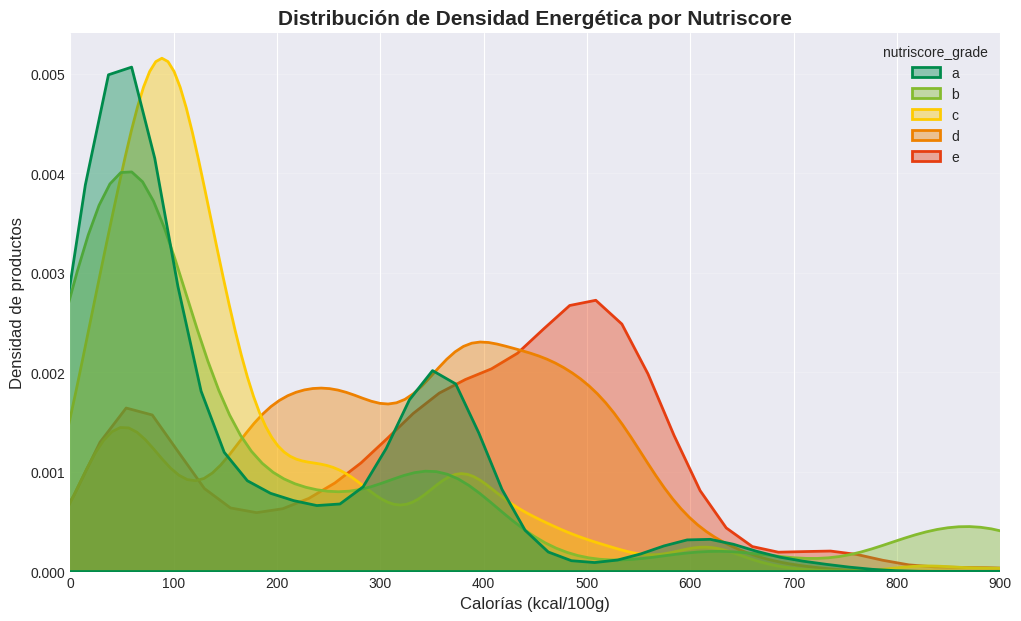

In [ ]:
plt.figure(figsize=(12, 7))
sns.kdeplot(
    data=df_products_copy,
    x='energy-kcal_100g',
    hue='nutriscore_grade',
    hue_order=['a', 'b', 'c', 'd', 'e'],
    palette=['#008b4c', '#85bb2f', '#fecb02', '#ee8100', '#e63e11'],
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2
)

plt.title('Distribución de Densidad Energética por Nutriscore', fontsize=15, fontweight='bold')
plt.xlabel('Calorías (kcal/100g)', fontsize=12)
plt.ylabel('Densidad de productos', fontsize=12)
plt.xlim(0, 900)
plt.grid(axis='y', alpha=0.2)

plt.show()

# **CREACIÓN DEL MODELO**

en esta parte nos centraremos en todo lo relacionado a preparar los datos para asegurarnos que el modelo sea lo más optimo posible

**FEATURE ENGINEERING**

Para este paso vamos a definir varias columnas binarias, en las cuales gracias a estas el modelo podrá interepretar datos relacionados con las etiquetas, una de estas estara relacionada con los productos que llevan bio o algo por el estilo, otra con los naturales y otra con los veganos.
Aqui el problema que encontramos es la grancantidad de etiquetas que podemos encontrar por tanto lo mas util sera mirar el dataset por encima e intentar poner todas las posibles.

In [ ]:
df_products_model=df_products_copy.copy()

In [ ]:
print(df_products_model[['labels_tags']].head(50).to_string())

                                                                                                                                                                                                                                          labels_tags
66                                                                                                                                                                                                                                                NaN
67                                                                                                                                                                                                                                                NaN
78                                                                                                                                                                                                                                                NaN
87              

In [ ]:
array_bio = [
    'bio', 'eco', 'organic', 'organico', 'ecologico', 'biologique', 'biologico',
    'agricultura ecologica', 'sustentable', 'sostenible', 'green', 'eco-friendly',
    'eu-organic', 'usda-organic', 'procedente de agricultura', 'es-eco', 'nl-bio',
    'agriculture biologique', 'bio-organic', 'ecocert', 'rainforest alliance',
    'huella de carbono', 'carbon neutral', 'carbon-footprint', 'cultivo sostenible',
    'respetuoso', 'planeta', 'proximidad', 'km0', 'kilometro 0', 'envirobox'
]

array_natural = [
    'natural', 'naturel', '100% natural', '100-natural', 'origen natural',
    'ingredientes naturales', 'puro', 'pure', 'artesano', 'artesanal',
    'tradicional', 'casero', 'sin aditivos', 'no additives', 'no-additives',
    'sin conservantes', 'sin colorantes', 'no preservatives', 'no colorings',
    'no-preservatives', 'no-colorings', 'raw', 'crudo', 'antigua receta',
    'como hecho en casa', 'sin refinar', 'unrefined', 'naturalmente',
    'naturally', 'autentico', 'real food', 'clean label', 'verified'
]

array_vegan = [
    'vegan', 'vegano', 'vegetarian', 'vegetariano', 'v-label', 'plant-based',
    '100% vegetal', 'base vegetal', 'cruelty-free', 'no animal testing',
    'sin huevo', 'sin leche', 'sin lactosa', 'sin productos animales',
    'egg-free', 'dairy-free', 'no animal ingredients', 'apto para veganos',
    'proteina vegetal', 'vegetal protein', 'the-vegan-society', 'vegan-action',
    'no-lactose', 'no-soy'
]

array_light = [
    '0%', 'zero', 'cero', 'light', 'diet', 'sin azucar', 'no sugar', 'no-sugar',
    'sin azucares añadidos', 'no added sugar', 'bajo en grasa', 'low fat',
    'low-fat', 'reduced fat', 'reduced-sugar', 'reducido en', 'menos calorias',
    'low calories', 'sin añadidos', 'sugar free', 'fat free', '0% grasa',
    '0% azucares', '0% azucar', 'sin azucares', 'stevia', 'edulcorado',
    'sweetened', 'low-or-no-sugar', 'naturally-fat-free'
]

array_proteina = [
    'protein', 'proteina', 'high protein', 'alto en proteina', 'plus protein',
    'fuente de proteina', 'enriquecido con proteina', 'musculo', 'sport',
    'whey', 'proteinas', 'pro', 'performance', 'isolada', 'isolate',
    'aminoacidos', 'bcaa', 'energy'
]

array_salud = [
    'equilibrado', 'nutritivo', 'saludable', 'healthy', 'bienestar', 'wellness',
    'vital', 'fitness', 'linea', 'silueta', 'cuidacol', 'digestivo', 'digestive',
    'superfood', 'superalimento', 'probioticos', 'prebioticos', 'defensas',
    'inmunitario', 'rico en fibra', 'high fiber', 'omega 3', 'antioxidante',
    'detox', 'limpia', 'purifica', 'nutritional'
]

array_riesgo_alto = ['e102', 'e110', 'e124', 'e127', 'e129', 'e133', 'e211', 'e250', 'e251', 'e951']
array_riesgo_medio = ['e150c', 'e202', 'e211', 'e433', 'e450', 'e621', 'e950', 'e954']


In [ ]:
patron_bio = '|'.join(array_bio)
patron_natural = '|'.join(array_natural)
patron_vegan = '|'.join(array_vegan)
patron_light = '|'.join(array_light)
patron_proteina = '|'.join(array_proteina)
patron_salud = '|'.join(array_salud)

In [ ]:
def detectar_marketing(df, patron):
    en_nombre = df['product_name'].str.contains(patron, case=False, na=False, regex=True)
    en_labels = df['labels_tags'].str.contains(patron, case=False, na=False, regex=True)
    return (en_nombre | en_labels).astype(int)


def detectar_aditivos_nocivos(tags):
    if pd.isna(tags): return 0
    tags = str(tags).lower()
    score = (sum(3 for a in array_riesgo_alto if a in tags) +
             sum(1 for a in array_riesgo_medio if a in tags))
    return score

In [ ]:
df_products_model['aditivos_score'] = df_products_model['additives_tags'].apply(detectar_aditivos_nocivos)

In [ ]:
df_products_model['f_bio'] = detectar_marketing(df_products_model, patron_bio)
df_products_model['f_natural'] = detectar_marketing(df_products_model, patron_natural)
df_products_model['f_vegan'] = detectar_marketing(df_products_model, patron_vegan)
df_products_model['f_light'] = detectar_marketing(df_products_model, patron_light)
df_products_model['f_proteina'] = detectar_marketing(df_products_model, patron_proteina)
df_products_model['f_salud'] = detectar_marketing(df_products_model, patron_salud)

print(" RESULTADOS DEL ESCANEO DE BINARIOS")
print("="*40)
columnas_mkt = ['f_bio', 'f_natural', 'f_vegan', 'f_light', 'f_proteina', 'f_salud']
for col in columnas_mkt:
    total = df_products_model[col].sum()
    print(f" {col:12} : {total} productos encontrados")

 RESULTADOS DEL ESCANEO DE BINARIOS
 f_bio        : 5289 productos encontrados
 f_natural    : 2295 productos encontrados
 f_vegan      : 2047 productos encontrados
 f_light      : 1030 productos encontrados
 f_proteina   : 831 productos encontrados
 f_salud      : 123 productos encontrados


In [ ]:
print(df_products_model.head(50).to_string())

             code                                            product_name                                        brands                         categories_en                                                                                                                                                                                                                                      labels_tags nutriscore_grade  energy-kcal_100g   fat_100g  saturated-fat_100g  sugars_100g  proteins_100g  salt_100g  additives_n                            additives_tags  aditivos_score  f_bio  f_natural  f_vegan  f_light  f_proteina  f_salud
66           1065                                   boisson à l'aloe vera                                     herbalife       plant-based foods and beverages                                                                                                                                                                                                                   

**ANÁLISIS DE CORRELLACIÓN**

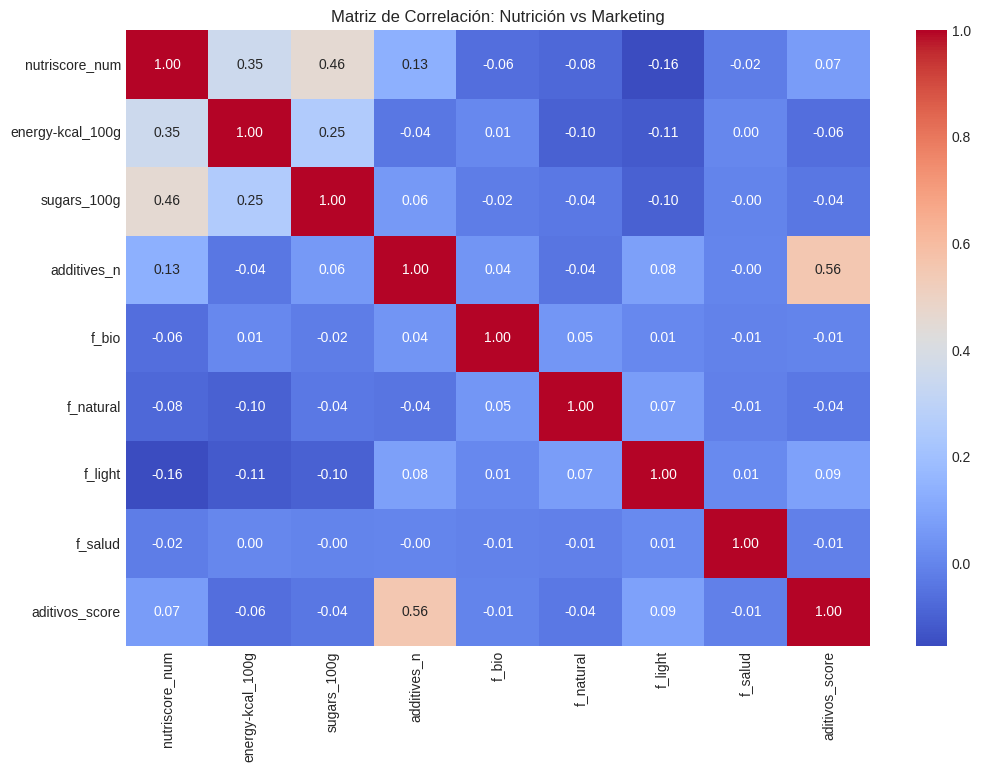

In [ ]:
mapa_nutri = {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5}
df_products_model['nutriscore_num'] = df_products_model['nutriscore_grade'].map(mapa_nutri)


cols_analisis = ['nutriscore_num', 'energy-kcal_100g', 'sugars_100g', 'additives_n',
                 'f_bio', 'f_natural', 'f_light', 'f_salud','aditivos_score']

corr = df_products_model[cols_analisis].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación: Nutrición vs Marketing")
plt.show()

En la matriz de correlación podemos observar que aunque un producto sea bio o natural no tiene apenas relacion con la calidad nutricional(nutriscore). Esto sugiere que se hace uso de estos terminos como estrategia de marketing que no suponene una mejora. Por otro lado con los productos que se suponen que tienen etiquetas como que tienen mayor proteina tiene muchois de ellos trampa porque tambien aumentan los numeros de aditivos y contienen peores notas nutricionales.

**K-MEANS**

In [ ]:
columnas_modelo = [
    'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
    'sugars_100g', 'proteins_100g', 'salt_100g', 'additives_n',
    'f_bio', 'f_natural', 'f_vegan', 'f_light', 'f_proteina', 'f_salud','aditivos_score'
]

df_product_train= df_products_model[columnas_modelo].fillna(0)
print(f"Dataset listo para entrenar con {df_product_train.shape[0]} productos y {df_product_train.shape[1]} características.")

Dataset listo para entrenar con 15350 productos y 14 características.


**ESCALADO**

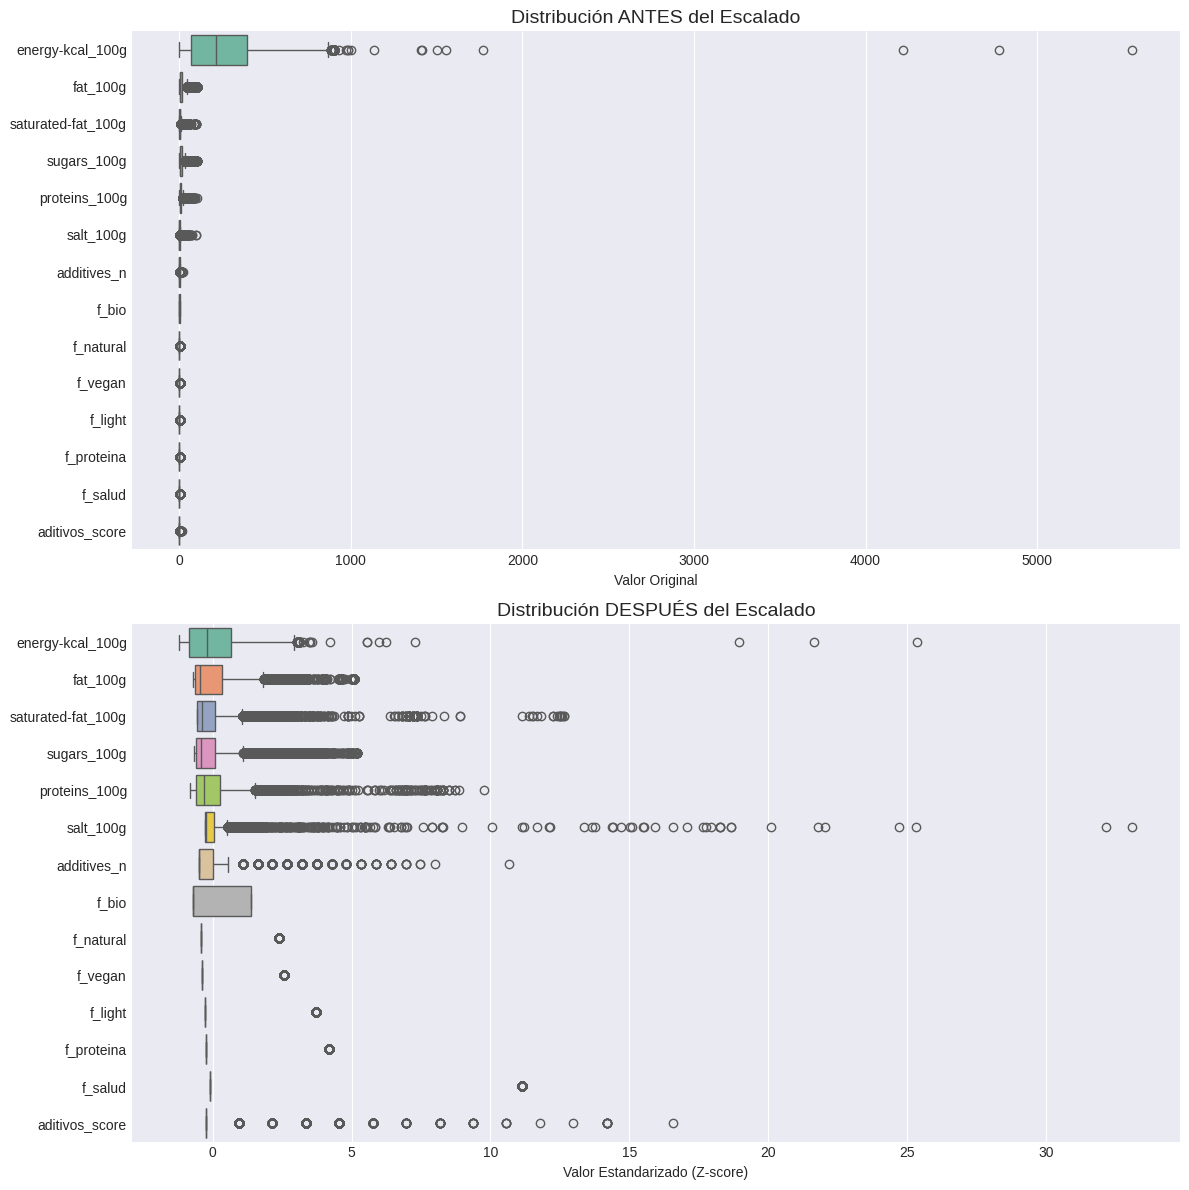

In [ ]:
scaler=StandardScaler()
df_product_train_scaled=scaler.fit_transform(df_product_train)
df_scaled=pd.DataFrame(df_product_train_scaled,columns=columnas_modelo)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

sns.boxplot(data=df_product_train, ax=ax1, orient='h', palette='Set2')
ax1.set_title('Distribución ANTES del Escalado', fontsize=14)
ax1.set_xlabel('Valor Original')

sns.boxplot(data=df_scaled, ax=ax2, orient='h', palette='Set2')
ax2.set_title('Distribución DESPUÉS del Escalado', fontsize=14)
ax2.set_xlabel('Valor Estandarizado (Z-score)')

plt.tight_layout()
plt.show()



In [ ]:
print('Estadísticas ANTES del escalado:')
print(df_product_train.describe().round(2))
print('------------')
print('Estadísticas DESPUÉS del escalado (media≈0, std≈1):')
print(df_scaled.describe().round(2))

Estadísticas ANTES del escalado:
       energy-kcal_100g  fat_100g  saturated-fat_100g  sugars_100g  \
count          15350.00  15350.00            15350.00     15350.00   
mean             251.09     12.03                4.17        11.75   
std              209.15     17.33                7.18        17.04   
min                0.06      0.00                0.00         0.00   
25%               70.00      0.80                0.20         1.30   
50%              211.13      3.80                1.30         4.70   
75%              392.00     18.00                4.88        13.00   
max             5555.00    100.00               95.00       100.00   

       proteins_100g  salt_100g  additives_n     f_bio  f_natural   f_vegan  \
count       15350.00   15350.00     15350.00  15350.00   15350.00  15350.00   
mean            7.64       0.86         0.96      0.34       0.15      0.13   
std             9.46       2.93         1.88      0.48       0.36      0.34   
min             0.00

**ELBOW METHOD**

/tmp/ipykernel_23165/1593590074.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23165/1593590074.py:35: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


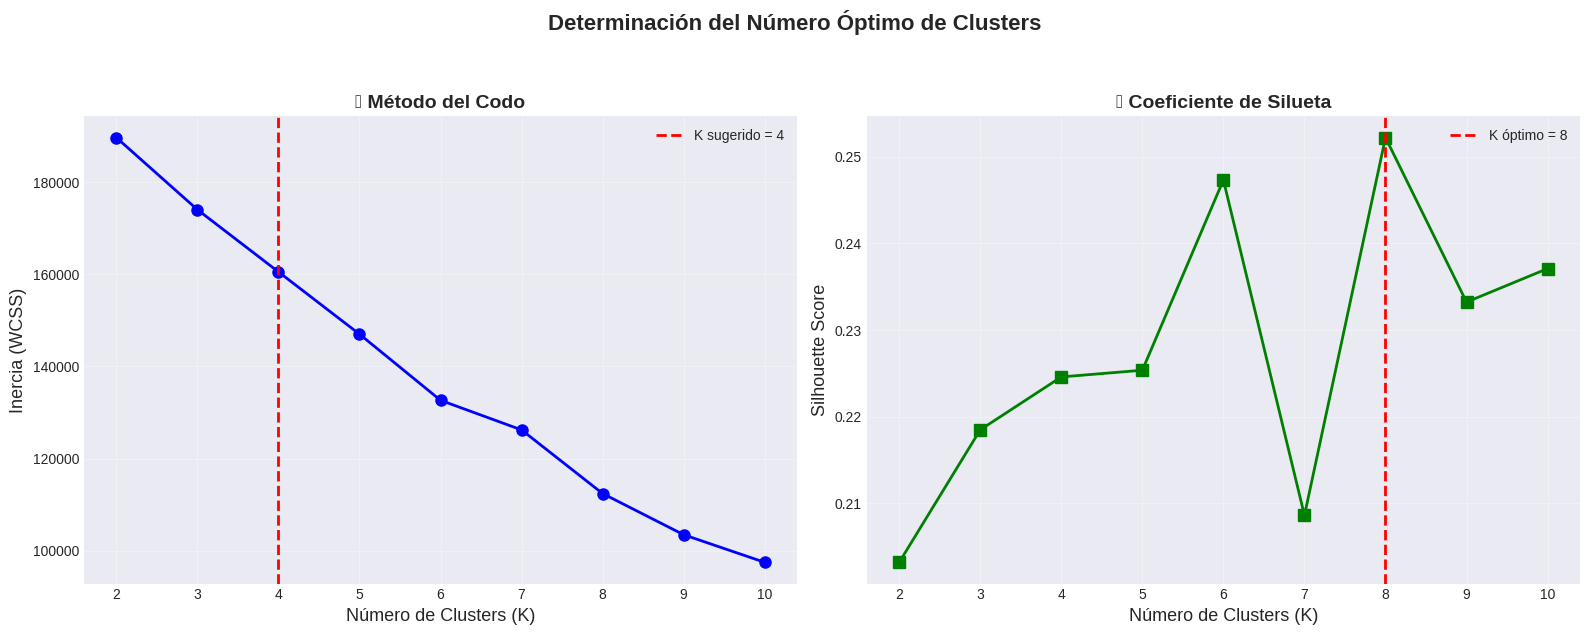

TABLA DE MÉTRICAS POR K
 K Inercia Silhouette
 2  189661     0.2032
 3  174021     0.2185
 4  160516     0.2246
 5  146993     0.2254
 6  132637     0.2473
 7  126208     0.2086
 8  112396     0.2522
 9  103459     0.2332
10   97462     0.2371
------------
Mejor K por Silhouette: 8
K sugerido por Codo: 4


In [ ]:

inercias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_product_train_scaled)
    inercias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_product_train_scaled, labels))

best_k_silhouette = list(K_range)[np.argmax(silhouette_scores)]
k_codo_sugerido = 4

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(K_range, inercias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=k_codo_sugerido, color='red', linestyle='--', linewidth=2, label=f'K sugerido = {k_codo_sugerido}')
axes[0].set_xlabel('Número de Clusters (K)', fontsize=13)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=13)
axes[0].set_title('📈 Método del Codo', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(x=best_k_silhouette, color='red', linestyle='--', linewidth=2, label=f'K óptimo = {best_k_silhouette}')
axes[1].set_xlabel('Número de Clusters (K)', fontsize=13)
axes[1].set_ylabel('Silhouette Score', fontsize=13)
axes[1].set_title('📊 Coeficiente de Silueta', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

plt.suptitle('Determinación del Número Óptimo de Clusters', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

tabla_k = pd.DataFrame({
    'K': list(K_range),
    'Inercia': [f'{v:.0f}' for v in inercias],
    'Silhouette': [f'{v:.4f}' for v in silhouette_scores]
})

print('TABLA DE MÉTRICAS POR K')
print(tabla_k.to_string(index=False))
print('------------')
print(f'Mejor K por Silhouette: {best_k_silhouette}')
print(f'K sugerido por Codo: {k_codo_sugerido}')

Como se puede apreciar el analisis de Silueta sugiere que lo mejor es agrupar en 8 grupos en este caso no tiene sentido debido a que se harian tantos nichos que no se podria hacer un analisis general por tanto tampoco se llegaria a apreciar una conclusión de forma clara, por tanto en este caso viendo los resultado eligire agruparlo por 4 o 5 clusters debido a que se harian grupos bastante claros.

**ENTRENAMIENTO Y PERFILADO**

In [ ]:

k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)

df_products_model['cluster'] = kmeans.fit_predict(df_product_train_scaled)

perfilado = df_products_model.groupby('cluster')[columnas_modelo].mean()

perfilado['count'] = df_products_model.groupby('cluster').size()

print("PERFILADO DE CLUSTERS")
display(perfilado.T)

PERFILADO DE CLUSTERS


cluster,0,1,2,3
energy-kcal_100g,161.334202,504.360569,260.689199,224.168201
fat_100g,4.111697,35.139333,8.759731,8.433649
saturated-fat_100g,1.409500,12.440313,2.393006,2.552646
sugars_100g,10.666319,15.384129,11.114049,10.365537
proteins_100g,5.453211,12.917501,7.576733,8.744925
salt_100g,0.789281,0.949566,0.598513,1.066325
additives_n,0.958617,0.882985,0.943089,1.120735
f_bio,0.314138,0.326817,0.292683,0.536483
f_natural,0.159856,0.097742,0.097561,0.198950
f_vegan,0.000000,0.036619,0.073171,1.000000


**ANALISIS DE CENTROIDES**

=== CENTROIDES EN ESCALA ORIGINAL (Gramos/Kcal) ===


,energy-kcal_100g,fat_100g,saturated-fat_100g,sugars_100g,proteins_100g,salt_100g,additives_n,f_bio,f_natural,f_vegan,f_light,f_proteina,f_salud,aditivos_score
Cluster 0,161.33,4.11,1.41,10.67,5.45,0.79,0.96,0.31,0.16,-0.00,0.07,0.04,-0.0,0.23
Cluster 1,504.36,35.14,12.44,15.38,12.92,0.95,0.88,0.33,0.10,0.04,0.04,0.06,0.0,0.18
Cluster 2,260.69,8.76,2.39,11.11,7.58,0.60,0.94,0.29,0.10,0.07,0.11,0.10,1.0,0.08
Cluster 3,224.17,8.43,2.55,10.37,8.74,1.07,1.12,0.54,0.20,1.00,0.09,0.13,-0.0,0.21


/tmp/ipykernel_23165/3949465568.py:27: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


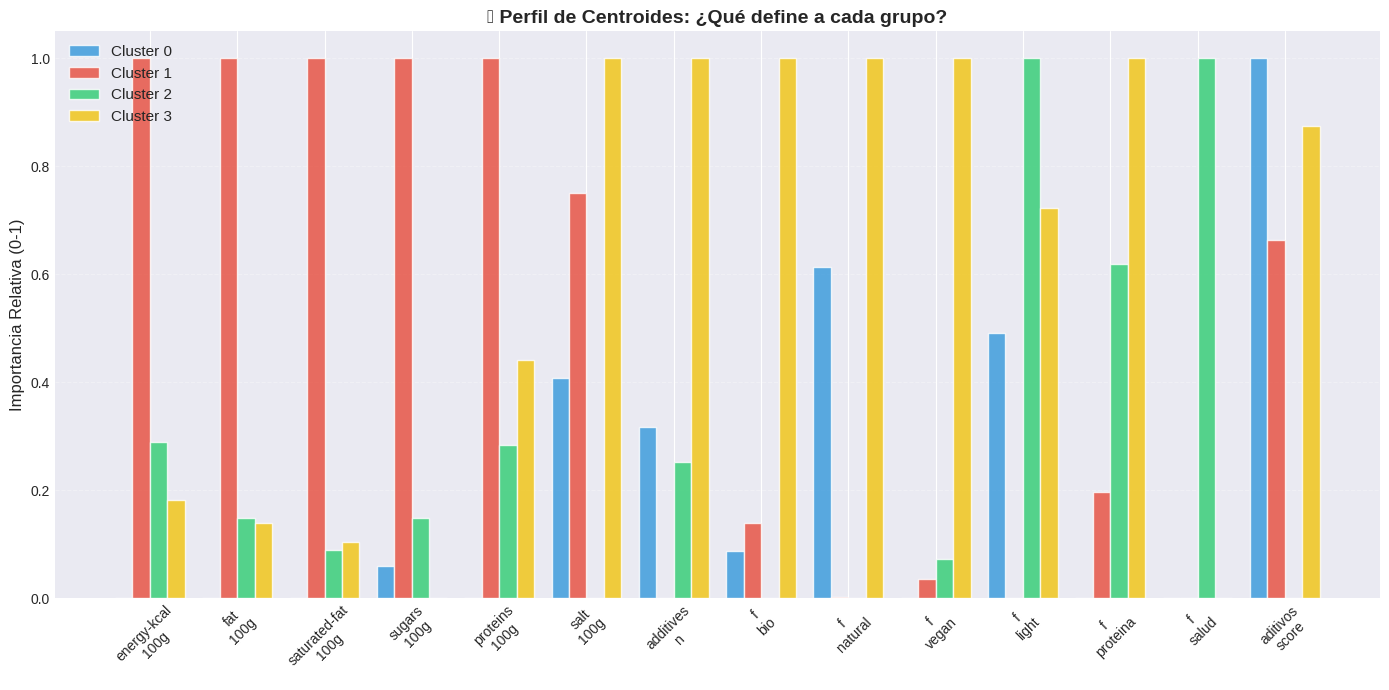

In [ ]:
centroides_originales = scaler.inverse_transform(kmeans.cluster_centers_)

df_centroides = pd.DataFrame(centroides_originales, columns=columnas_modelo)
df_centroides.index = [f'Cluster {i}' for i in range(k_final)]

print('CENTROIDES EN ESCALA ORIGINAL (Gramos/Kcal)')
display(df_centroides.round(2))

fig, ax = plt.subplots(figsize=(14, 7))

df_centroides_norm = (df_centroides - df_centroides.min()) / (df_centroides.max() - df_centroides.min())

colors_cluster = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
x = np.arange(len(columnas_modelo))
width = 0.20

for i, (cluster, color) in enumerate(zip(df_centroides_norm.index, colors_cluster)):
    ax.bar(x + i*width, df_centroides_norm.loc[cluster], width,
           label=cluster, color=color, alpha=0.8, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f.replace('_', '\n') for f in columnas_modelo], fontsize=10, rotation=45)
ax.set_ylabel('Importancia Relativa (0-1)', fontsize=12)
ax.set_title('Perfil de Centroides: ¿Qué define a cada grupo?', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

En este caso se han delimitado 4 clusters.

En cuanto al cluster 0 podemos ver que son productos que tiene gran cantidad de aditivos y que algunos se presentancomo light, natural y con bastante sal.

En cuanto al cluster 1 podemos ver que son productos con una gran cantidad de calorias, grasas, azucares, proteinas, sal y aditivos lo que indica que pueden ser procesados como bolleria etc...

En cuanto al cluster 2 parece que esta mas relacionado con productos realmente sanos sin una gran campaña de marketing falso y con una presencia nula de aditivos.

En cuanto al cluster 3 podemos ver producto con una gran campaña de marketing falso debido a que muchos de estos llevan una gran cantidad de aditivos

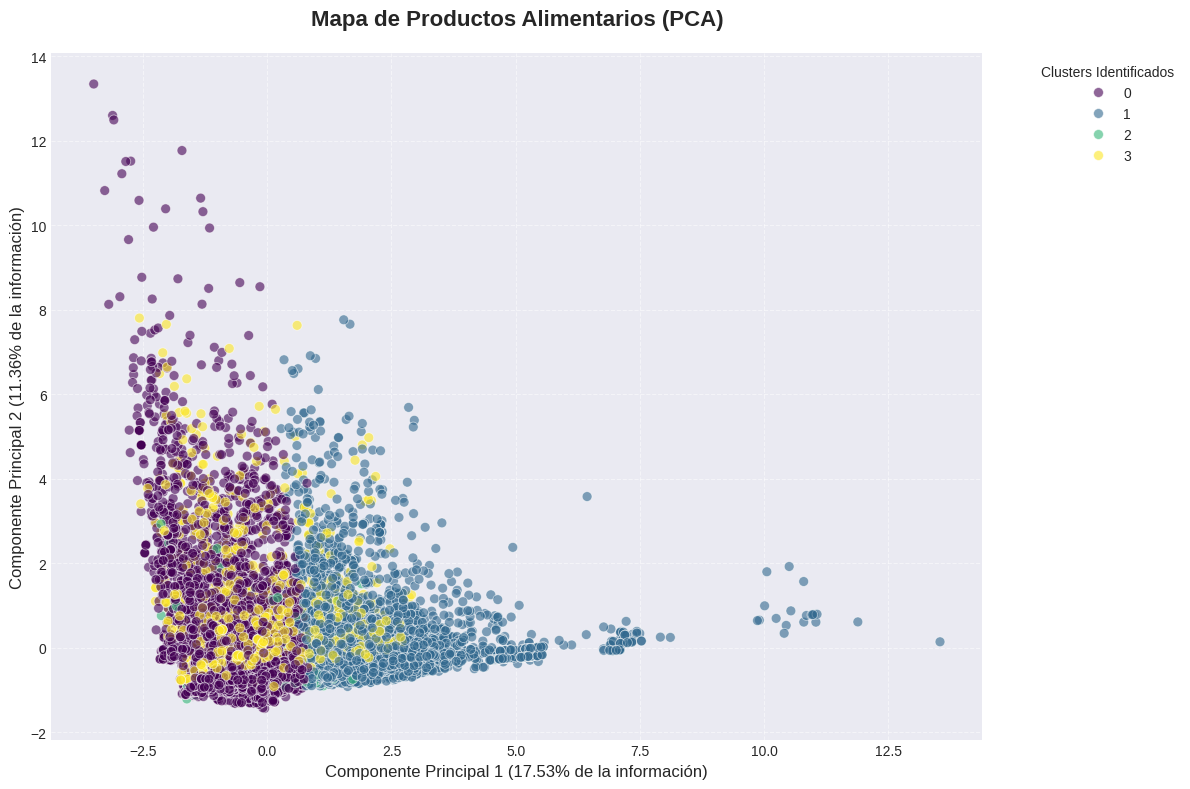

--- Peso de cada variable en los ejes ---
                         PC1       PC2
fat_100g            0.575156  0.067138
energy-kcal_100g    0.562816  0.041199
saturated-fat_100g  0.513302  0.071947
proteins_100g       0.215838  0.140657
sugars_100g         0.096044 -0.076644
salt_100g           0.031072  0.116519
f_bio               0.010801  0.089071
f_proteina         -0.012261  0.181921
f_salud            -0.012978 -0.015354
f_vegan            -0.016539  0.107732
f_natural          -0.079830 -0.064295
additives_n        -0.080489  0.646339
aditivos_score     -0.080532  0.657498
f_light            -0.110151  0.205720


In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(df_product_train_scaled)

varianza = pca.explained_variance_ratio_ * 100

df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_products_model['cluster'].values

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    data=df_pca,
    palette='viridis',
    alpha=0.6,
    edgecolor='w',
    s=50
)

plt.title('Mapa de Productos Alimentarios (PCA)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f'Componente Principal 1 ({varianza[0]:.2f}% de la información)', fontsize=12)
plt.ylabel(f'Componente Principal 2 ({varianza[1]:.2f}% de la información)', fontsize=12)

plt.legend(title='Clusters Identificados', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=columnas_modelo
)
print("--- Peso de cada variable en los ejes ---")
print(loadings.sort_values(by='PC1', ascending=False))